In [2]:
import numpy as np
import matplotlib.pyplot as plt

Bài 3

In [10]:
epsilon = 0.5 * 10**(-7)

k = 1
x = 1
S = 1 + x
while x > (epsilon/3):
    x = x / (k + 1)
    S = S + x
    k = k + 1
print(S)

2.7182818282861687


In [ ]:
import math

def f(x):
    return math.sin(x)

def tinh_pi(a, b, epsilon):
    print(f"{'k':>4} | {'a':>12} | {'b':>12} | {'mid':>12} | {'f(mid)':>14} | {'b-a':>12}")
    print("-" * 75)
    k = 0
    while (b - a) > 2 * epsilon:
        mid = (a + b) / 2
        k += 1
        print(f"{k:>4} | {a:>12.8f} | {b:>12.8f} | {mid:>12.8f} | {f(mid):>14.8e} | {b-a:>12.2e}")
        if f(mid) == 0:
            return mid
        elif f(a) * f(mid) < 0:
            b = mid
        else:
            a = mid
    print("-" * 75)
    return (a + b) / 2

# ── Áp dụng ──
epsilon = 0.5e-7
pi = tinh_pi(3, 3.2, epsilon)
print(f"\npi ≈ {pi:.7f}")
print(f"Sai số: {abs(pi - math.pi):.2e}")

Bài 4

In [ ]:
import math

def f(x, a, n):
    return x**n - a

def tinh_can(a, n, epsilon):
    if a == 0:
        return 0
    if a < 0 and n % 2 == 0:
        raise ValueError("Không có nghiệm thực: a < 0 và n chẵn")

    if a > 0:
        L, R = 0, max(1, a)
    else:
        L, R = -max(1, abs(a)), 0

    print(f"{'k':>4} | {'L':>12} | {'R':>12} | {'mid':>12} | {'f(mid)':>14} | {'R-L':>12}")
    print("-" * 75)
    k = 0
    while (R - L) > 2 * epsilon:
        mid = (L + R) / 2
        k += 1
        print(f"{k:>4} | {L:>12.8f} | {R:>12.8f} | {mid:>12.8f} | {f(mid, a, n):>14.8e} | {R-L:>12.2e}")
        if f(mid, a, n) == 0:
            return mid
        elif f(L, a, n) * f(mid, a, n) < 0:
            R = mid
        else:
            L = mid

    print("-" * 75)
    return (L + R) / 2

# ── Áp dụng: căn bậc 3 của 17, 6 chữ số đáng tin ──
a, n = 17, 3
epsilon = 0.5 * 10**(-6)

ket_qua = tinh_can(a, n, epsilon)
chinh_xac = a ** (1/n)

print(f"\nCăn bậc {n} của {a} ≈ {ket_qua:.10f}")
print(f"Giá trị chính xác      : {chinh_xac:.10f}")
print(f"Sai số thực tế         : {abs(ket_qua - chinh_xac):.10f}")

Bài 5

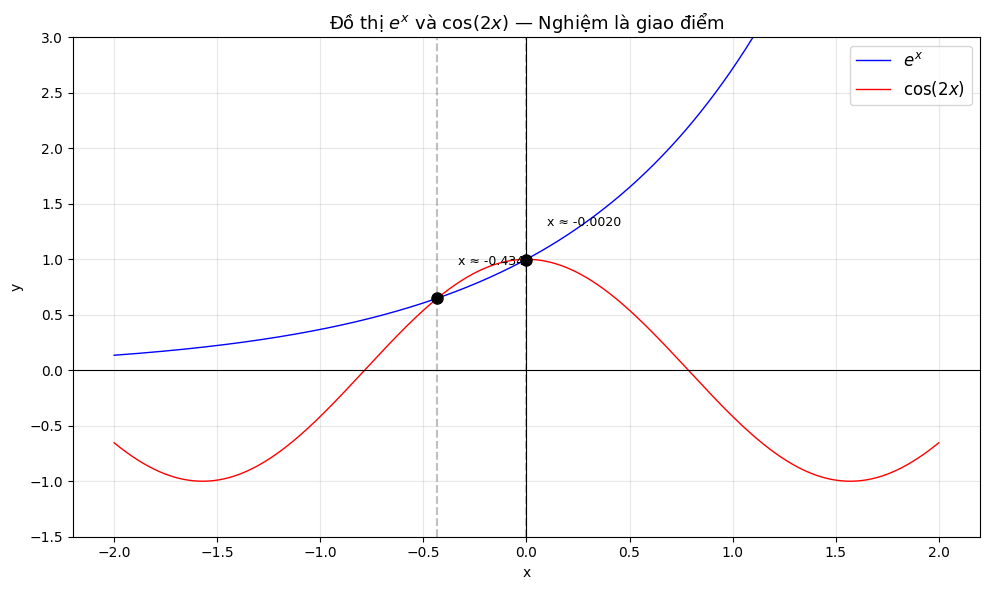

In [13]:
# Tạo dải giá trị x
x = np.linspace(-2, 2, 1000)

# Tính giá trị hàm số
y1 = np.exp(x)
y2 = np.cos(2 * x)

# Vẽ đồ thị
plt.figure(figsize=(10, 6))
plt.plot(x, y1, label=r'$e^x$', color='blue', linewidth=1)
plt.plot(x, y2, label=r'$\cos(2x)$', color='red', linewidth=1)

# Đánh dấu giao điểm (nghiệm)
# f(x) = e^x - cos(2x), tìm chỗ đổi dấu
f = y1 - y2
sign_changes = np.where(np.diff(np.sign(f)))[0]
for idx in sign_changes:
    x_approx = x[idx]
    plt.axvline(x=x_approx, color='gray', linestyle='--', alpha=0.5)
    plt.plot(x_approx, np.exp(x_approx), 'ko', markersize=8)
    plt.annotate(f'x ≈ {x_approx:.4f}',
                 xy=(x_approx, np.exp(x_approx)),
                 xytext=(x_approx + 0.1, np.exp(x_approx) + 0.3),
                 fontsize=9)

# Định dạng đồ thị
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.title(r'Đồ thị $e^x$ và $\cos(2x)$ — Nghiệm là giao điểm', fontsize=13)
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(-1.5, 3)
plt.tight_layout()
plt.show()

In [3]:
def f(x):
    return np.exp(x) - np.cos(2 * x)

def bisection(f, a, b, epsilon=1e-7):
    assert f(a) * f(b) < 0, "f(a) và f(b) phải trái dấu"
    print(f"{'k':>4} | {'a':>12} | {'b':>12} | {'mid':>12} | {'f(mid)':>14} | {'b-a':>12}")
    print("-" * 75)
    k = 0
    while (b - a) > 2 * epsilon:
        mid = (a + b) / 2
        k += 1
        print(f"{k:>4} | {a:>12.8f} | {b:>12.8f} | {mid:>12.8f} | {f(mid):>14.8e} | {b-a:>12.2e}")
        if f(mid) == 0:
            return mid
        elif f(a) * f(mid) < 0:
            b = mid
        else:
            a = mid
    print("-" * 75)
    return (a + b) / 2

epsilon = 1/2 * 10**(-5)
root = bisection(f, -0.5, -0.2, epsilon=epsilon)
print(f"\nNghiệm ≈ {root:.10f}   |   Sai số tuyệt đối < {epsilon}")

   k |            a |            b |          mid |         f(mid) |          b-a
---------------------------------------------------------------------------
   1 |  -0.50000000 |  -0.20000000 |  -0.35000000 | -6.01540976e-02 |     3.00e-01
   2 |  -0.50000000 |  -0.35000000 |  -0.42500000 | -6.21336076e-03 |     1.50e-01
   3 |  -0.50000000 |  -0.42500000 |  -0.46250000 | 2.78728151e-02 |     7.50e-02
   4 |  -0.46250000 |  -0.42500000 |  -0.44375000 | 1.02730702e-02 |     3.75e-02
   5 |  -0.44375000 |  -0.42500000 |  -0.43437500 | 1.88787955e-03 |     1.87e-02
   6 |  -0.43437500 |  -0.42500000 |  -0.42968750 | -2.19858172e-03 |     9.37e-03
   7 |  -0.43437500 |  -0.42968750 |  -0.43203125 | -1.64268136e-04 |     4.69e-03
   8 |  -0.43437500 |  -0.43203125 |  -0.43320312 | 8.59581865e-04 |     2.34e-03
   9 |  -0.43320312 |  -0.43203125 |  -0.43261719 | 3.47100226e-04 |     1.17e-03
  10 |  -0.43261719 |  -0.43203125 |  -0.43232422 | 9.12768006e-05 |     5.86e-04
  11 |  -0.4323242

Bài 6: Giải phương trình $x^5 - 3x^3 + 2x^2 - x + 5 = 0$ với nghiệm có sai lệch không vượt quá $0.05\%$.


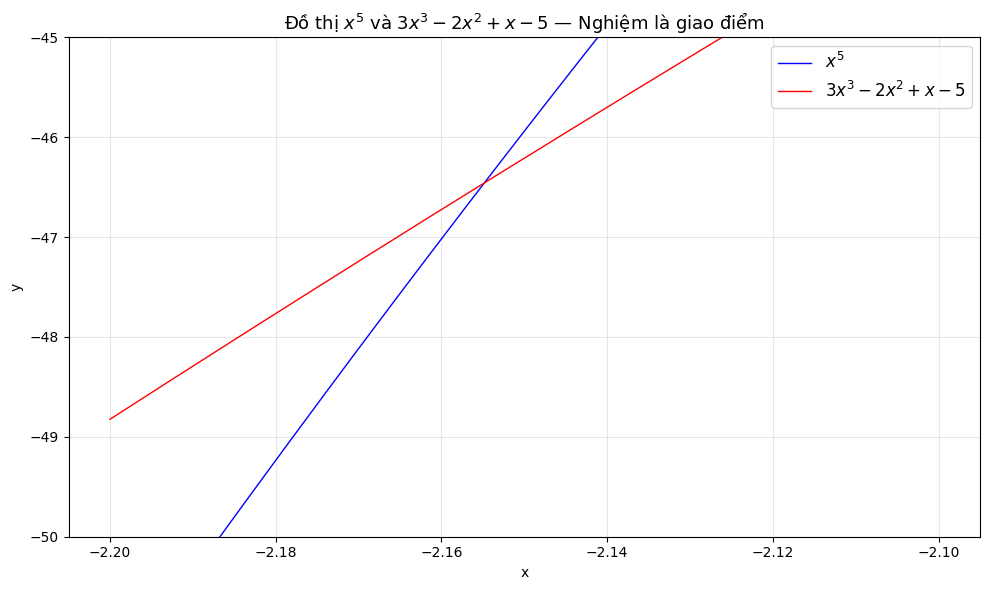

In [49]:
# Tạo dải giá trị x
x = np.linspace(-2.2, -2.1, 1000)

# Tính giá trị hàm số
y1 = x**5
y2 = 3*x**3 - 2*x**2 + x - 5

# Vẽ đồ thị
plt.figure(figsize=(10, 6))
plt.plot(x, y1, label=r'$x^5$', color='blue', linewidth=1)
plt.plot(x, y2, label=r'$3x^3 - 2x^2 + x - 5$', color='red', linewidth=1)

# Đánh dấu giao điểm (nghiệm)
# f(x) = e^x - cos(2x), tìm chỗ đổi dấu
# f = y1 - y2
# sign_changes = np.where(np.diff(np.sign(f)))[0]
# for idx in sign_changes:
#     x_approx = x[idx]
#     plt.axvline(x=x_approx, color='gray', linestyle='--', alpha=0.5)
#     plt.plot(x_approx, np.exp(x_approx), 'ko', markersize=8)
#     plt.annotate(f'x ≈ {x_approx:.4f}',
#                  xy=(x_approx, np.exp(x_approx)),
#                  xytext=(x_approx + 0.1, np.exp(x_approx) + 0.3),
#                  fontsize=9)

# Định dạng đồ thị
# plt.axhline(0, color='black', linewidth=0.8) #trục hoành
# plt.axvline(0, color='black', linewidth=0.8) #trục tung
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.title(r'Đồ thị $x^5$ và $3x^3 - 2x^2 + x - 5$ — Nghiệm là giao điểm', fontsize=13)
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(-50, -45)
plt.tight_layout()
plt.show()

In [4]:
def f(x):
    return x**5 - (3*x**3 - 2*x**2 + x - 5)

def bisection(f, a, b, epsilon=1e-7):
    assert f(a) * f(b) < 0, "f(a) và f(b) phải trái dấu"
    print(f"{'k':>4} | {'a':>12} | {'b':>12} | {'mid':>12} | {'f(mid)':>14} | {'b-a':>12}")
    print("-" * 75)
    k = 0
    while (b - a) > 2 * epsilon:
        mid = (a + b) / 2
        k += 1
        print(f"{k:>4} | {a:>12.8f} | {b:>12.8f} | {mid:>12.8f} | {f(mid):>14.8e} | {b-a:>12.2e}")
        if f(mid) == 0:
            return mid
        elif f(a) * f(mid) < 0:
            b = mid
        else:
            a = mid
    print("-" * 75)
    return (a + b) / 2

epsilon = 1/2 * 10**(-5)
root = bisection(f, -2.16, -2.14, epsilon=epsilon)
print(f"\nNghiệm ≈ {root:.10f}   |   Sai số tuyệt đối < {epsilon}")

   k |            a |            b |          mid |         f(mid) |          b-a
---------------------------------------------------------------------------
   1 |  -2.16000000 |  -2.14000000 |  -2.15000000 | 2.69986562e-01 |     2.00e-02
   2 |  -2.16000000 |  -2.15000000 |  -2.15500000 | -1.01448473e-02 |     1.00e-02
   3 |  -2.15500000 |  -2.15000000 |  -2.15250000 | 1.30410598e-01 |     5.00e-03
   4 |  -2.15500000 |  -2.15250000 |  -2.15375000 | 6.02555641e-02 |     2.50e-03
   5 |  -2.15500000 |  -2.15375000 |  -2.15437500 | 2.50860624e-02 |     1.25e-03
   6 |  -2.15500000 |  -2.15437500 |  -2.15468750 | 7.47828752e-03 |     6.25e-04
   7 |  -2.15500000 |  -2.15468750 |  -2.15484375 | -1.33135942e-03 |     3.12e-04
   8 |  -2.15484375 |  -2.15468750 |  -2.15476563 | 3.07394411e-03 |     1.56e-04
   9 |  -2.15484375 |  -2.15476563 |  -2.15480469 | 8.71412368e-04 |     7.81e-05
  10 |  -2.15484375 |  -2.15480469 |  -2.15482422 | -2.29943519e-04 |     3.91e-05
  11 |  -2.15482422

---

## Phương pháp Chia Đôi (Bisection Method) — Thuật Toán Tổng Quát

### 1. Cơ sở lý thuyết

**Định lý Bolzano (Intermediate Value Theorem):**  
Nếu $f$ liên tục trên $[a, b]$ và $f(a) \cdot f(b) < 0$, thì tồn tại ít nhất một nghiệm $x^* \in (a, b)$ sao cho $f(x^*) = 0$.

**Khoảng cách ly nghiệm $[a, b]$** là khoảng thoả mãn đồng thời:
- $f$ liên tục trên $[a, b]$
- $f(a) \cdot f(b) < 0$ (hàm đổi dấu qua khoảng)
- Phương trình có **đúng một nghiệm** trong khoảng đó

---

### 2. Ý tưởng thuật toán

Tại mỗi bước, rút ngắn khoảng $[a_k, b_k]$ xuống còn một nửa bằng cách chọn điểm giữa $m_k = \dfrac{a_k + b_k}{2}$:

$$
[a_{k+1},\, b_{k+1}] = \begin{cases}
[a_k,\; m_k] & \text{nếu } f(a_k)\cdot f(m_k) < 0 \\
[m_k,\; b_k] & \text{nếu } f(m_k)\cdot f(b_k) < 0
\end{cases}
$$

---

### 3a. Thuật toán dùng Sai số Tiên nghiệm (A Priori)

> **Sai số tiên nghiệm** — ước lượng sai số được tính **trước** khi chạy vòng lặp, chỉ dựa trên dữ liệu đầu vào $(a_0, b_0, \varepsilon)$. Không cần biết nghiệm $x^*$.

Sau $n$ bước, sai số đảm bảo:

$$|m_n - x^*| \leq \frac{b_0 - a_0}{2^{n+1}}$$

Suy ra số bước **tối thiểu** cần thực hiện để đạt sai số $\varepsilon$:

$$\boxed{n \;\geq\; \left\lceil \log_2 \frac{b_0 - a_0}{2\varepsilon} \right\rceil}$$

**Pseudocode (điều kiện dừng: độ rộng khoảng):**

```
Input : f, a, b, ε
Output: x*

Bước 0: Kiểm tra f(a)·f(b) < 0. Nếu không → báo lỗi và dừng.
        Tính n = ⌈log₂((b − a) / 2ε)⌉   ← số bước đã biết trước

Lặp k = 1, 2, ..., n:
    Bước 1: m ← (a + b) / 2
    Bước 2: Nếu f(m) = 0      → trả về m  (nghiệm chính xác)
    Bước 3: Nếu f(a)·f(m) < 0 → b ← m
            Ngược lại          → a ← m

Trả về x* = (a + b) / 2
```

**Ưu điểm:** Biết trước chính xác số bước cần chạy.  
**Nhược điểm:** Có thể chạy dư bước nếu thuật toán hội tụ sớm hơn dự đoán.

---

### 3b. Thuật toán dùng Sai số Hậu nghiệm (A Posteriori)

> **Sai số hậu nghiệm** — ước lượng sai số được tính **sau mỗi bước lặp**, dựa trên sự thay đổi giữa hai xấp xỉ liên tiếp $m_k$ và $m_{k-1}$.

Tiêu chuẩn dừng:

$$|m_k - m_{k-1}| \leq \varepsilon$$

Điều này phản ánh mức độ "ổn định" của xấp xỉ — khi hai điểm giữa liên tiếp gần nhau đủ, ta coi nghiệm đã hội tụ.

**Pseudocode (điều kiện dừng: hai xấp xỉ liên tiếp):**

```
Input : f, a, b, ε
Output: x*

Bước 0: Kiểm tra f(a)·f(b) < 0. Nếu không → báo lỗi và dừng.
        m_prev ← a   (xấp xỉ ban đầu, có thể chọn a hoặc b)

Lặp k = 1, 2, 3, ...:
    Bước 1: m ← (a + b) / 2
    Bước 2: Nếu f(m) = 0         → trả về m  (nghiệm chính xác)
    Bước 3: Nếu |m − m_prev| ≤ ε → trả về m  (đạt độ chính xác hậu nghiệm)
    Bước 4: Nếu f(a)·f(m) < 0    → b ← m
            Ngược lại             → a ← m
    Bước 5: m_prev ← m

Trả về x* = m
```

**Ưu điểm:** Dừng sớm hơn nếu nghiệm hội tụ nhanh; không cần tính trước số bước.  
**Nhược điểm:** Không đảm bảo sai số tuyệt đối chặt như tiên nghiệm (phụ thuộc vào độ trơn của $f$).

---

### 4. So sánh hai tiêu chuẩn dừng

| Tiêu chí | Sai số tiên nghiệm | Sai số hậu nghiệm |
|:---------|:------------------:|:-----------------:|
| **Điều kiện dừng** | $b_k - a_k \leq 2\varepsilon$ | $\|m_k - m_{k-1}\| \leq \varepsilon$ |
| **Biết trước số bước?** | Có — $n = \lceil\log_2\frac{b_0-a_0}{2\varepsilon}\rceil$ | Không |
| **Đảm bảo sai số chặt?** | Có — $\|m_n - x^*\| \leq \varepsilon$ | Không tuyệt đối |
| **Có thể dừng sớm hơn?** | Không | Có |
| **Phù hợp khi** | Cần đảm bảo độ chính xác | Cần tiết kiệm bước lặp |

---

### 5. Ưu & Nhược điểm của phương pháp Chia Đôi

| Ưu điểm | Nhược điểm |
|:--------|:-----------|
| Luôn hội tụ nếu điều kiện ban đầu thoả mãn | Hội tụ chậm — tuyến tính, bậc 1 |
| Không cần đạo hàm $f'(x)$ | Phải biết **khoảng cách ly nghiệm** $[a, b]$ trước |
| Đơn giản, dễ cài đặt và kiểm chứng | Không áp dụng khi nghiệm có bậc chẵn (tiếp xúc trục $Ox$) |
| Sai số được kiểm soát chặt bằng công thức | Mỗi lần chạy chỉ tìm được **một** nghiệm |